
Importing necessary Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



PART A: DATA COLLECTION AND PREPROCESSING



<h3><b>
Step 1: Load the dataset
</b></h3>

In [2]:
df = pd.read_csv("Student Awareness Survey (Responses) - Form Responses 1.csv")

# Rename columns to shorter aliases for convenience
df = df.rename(columns={
    "Your CIA % of last semester":              "CIA_percent",
    "Your GPA of last semester":                "GPA",
    "Your maximum attendance % till last semester": "Attendance_percent",
})



<h3><b>
Step 2: Display first 5 rows
</b></h3>

In [3]:
print(df[["CIA_percent", "GPA", "Attendance_percent"]].head())



  CIA_percent   GPA Attendance_percent
0          69  3.40                 98
1          75  3.69                 95
2          82  3.41                 95
3          91  3.60                 92
4          70  3.54                 93


<h3><b>
Step 3: Dataset dimensions
</b></h3>

In [4]:
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset dimensions: 50 rows × 15 columns


<h3><b>
Step 4: Identify missing values
</b></h3>

In [5]:
print(df[["CIA_percent", "GPA", "Attendance_percent"]].isnull().sum())



CIA_percent           0
GPA                   0
Attendance_percent    0
dtype: int64


<h3><b>
Step 5: Handle null values
</b></h3>
Drop rows where any of the 3 key columns is null

In [6]:
before = len(df)
df = df.dropna(subset=["CIA_percent", "GPA", "Attendance_percent"])
print(f"Rows before dropping nulls: {before} | After: {len(df)}")


Rows before dropping nulls: 50 | After: 50


<h3><b>
Step 6: Convert to numeric
</b></h3>

In [7]:
df["CIA_percent"]        = pd.to_numeric(df["CIA_percent"],        errors="coerce")
df["GPA"]                = pd.to_numeric(df["GPA"],                errors="coerce")
df["Attendance_percent"] = pd.to_numeric(df["Attendance_percent"], errors="coerce")
df = df.dropna(subset=["CIA_percent", "GPA", "Attendance_percent"])
print(f"\nDtypes after conversion:")
print(df[["CIA_percent", "GPA", "Attendance_percent"]].dtypes)


Dtypes after conversion:
CIA_percent           float64
GPA                   float64
Attendance_percent    float64
dtype: object


<h3><b>
Step 7: Remove duplicates
</b></h3>

In [8]:
before = len(df)
df = df.drop_duplicates()
print(f"Rows before: {before} | After: {len(df)}")

Rows before: 39 | After: 39


<h3><b>
Step 8: Remove obvious outlier — one GPA of 8.0 exists on a ~4-point scale
</b></h3>
Likely a data entry error; all other values are between 2.74 and 3.90)


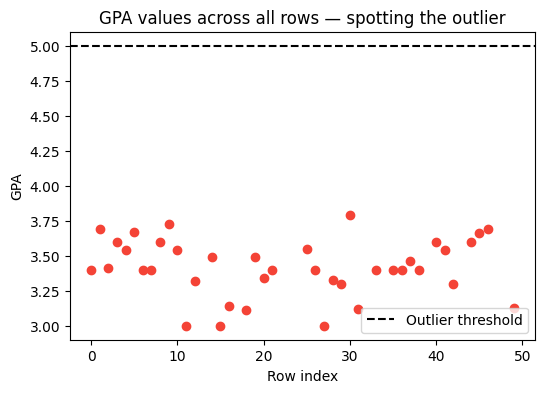

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(df.index, df["GPA"], color="#F44336")
plt.axhline(y=5.0, color="black", linestyle="--", label="Outlier threshold")
plt.title("GPA values across all rows — spotting the outlier")
plt.xlabel("Row index")
plt.ylabel("GPA")
plt.legend()
plt.show()

**Justification:** This plot visually isolates the single GPA = 8.0
entry far above the rest of the data points, which cluster between
2.74 and 3.90. Seeing it plotted against the threshold line makes the
case for removing it as a data-entry error, rather than a genuine high
achiever, much clearer than reading a printed value alone.

In [10]:
outlier_mask = df["GPA"] > 5.0
print(f"Outliers detected (GPA > 5): {outlier_mask.sum()} row(s) — {df.loc[outlier_mask, 'GPA'].values}")
df = df[~outlier_mask].reset_index(drop=True)
print(f"         Rows after removing outlier: {len(df)}")


Outliers detected (GPA > 5): 0 row(s) — []
         Rows after removing outlier: 39


<h3><b>Step 9: Statistical summary of working columns
</b></h3>

In [11]:
print("Statistical summary:")
print(df[["CIA_percent", "GPA", "Attendance_percent"]].describe().round(3))

Statistical summary:
       CIA_percent     GPA  Attendance_percent
count       39.000  39.000              39.000
mean        72.547   3.419              94.219
std          5.969   0.207               3.779
min         60.000   3.000              85.000
25%         69.890   3.325              92.500
50%         71.780   3.400              95.000
75%         75.600   3.575              96.270
max         91.000   3.790             100.000


<h3><b>Visual exploration of the data
</b></h3>

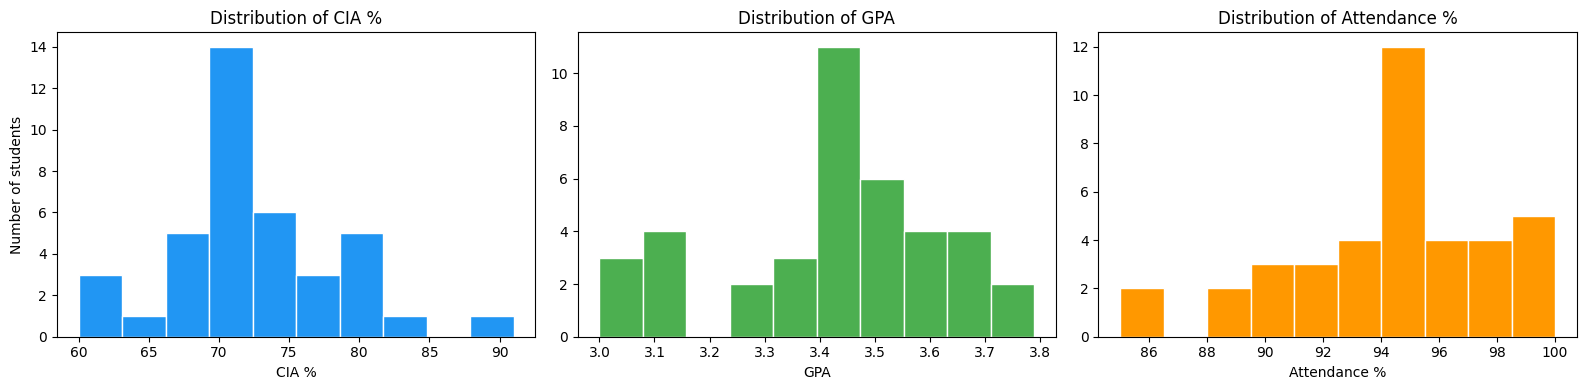

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["CIA_percent"], bins=10, color="#2196F3", edgecolor="white")
axes[0].set_title("Distribution of CIA %")
axes[0].set_xlabel("CIA %")
axes[0].set_ylabel("Number of students")

axes[1].hist(df["GPA"], bins=10, color="#4CAF50", edgecolor="white")
axes[1].set_title("Distribution of GPA")
axes[1].set_xlabel("GPA")

axes[2].hist(df["Attendance_percent"], bins=10, color="#FF9800", edgecolor="white")
axes[2].set_title("Distribution of Attendance %")
axes[2].set_xlabel("Attendance %")

plt.tight_layout()
plt.show()

**Justification:** These histograms show how each variable is spread
across the class. CIA% and Attendance% appear roughly clustered around
their respective means with some spread, while GPA is tightly
concentrated around 3.3–3.6, with very little variation. A dependent
variable with low spread is naturally harder to predict accurately,
which foreshadows the low R² values seen later in the regression
results.

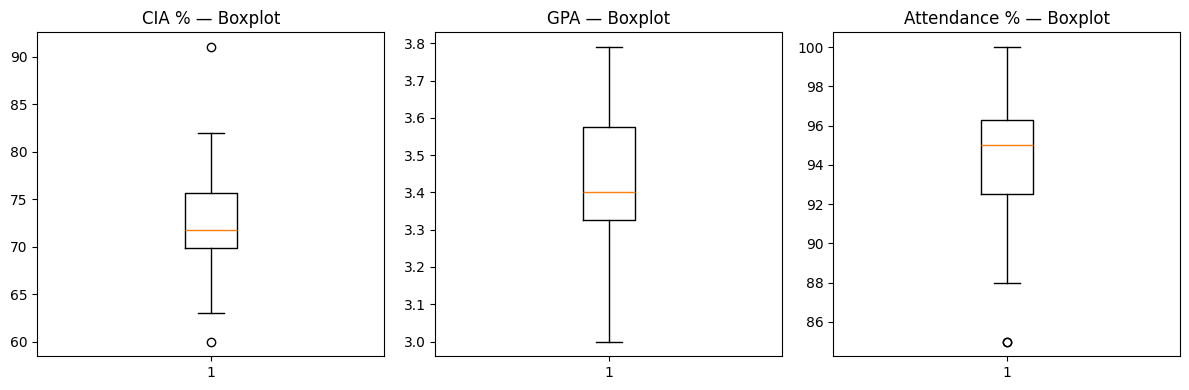

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].boxplot(df["CIA_percent"])
axes[0].set_title("CIA % — Boxplot")

axes[1].boxplot(df["GPA"])
axes[1].set_title("GPA — Boxplot")

axes[2].boxplot(df["Attendance_percent"])
axes[2].set_title("Attendance % — Boxplot")

plt.tight_layout()
plt.show()

**Justification:** Boxplots make it easy to spot outliers and
understand quartile spread at a glance. They confirm that, aside from
the GPA outlier already identified and removed in Step 8, the
remaining values for all three variables are reasonably well-behaved
with no extreme spread — supporting the decision to proceed with
linear regression without further outlier treatment.


OLS Manual Computation - Defining a function for OLS


In [14]:
def ols_slope_intercept(X, y):
    """
    Ordinary Least Squares formulas:
        slope (m)     = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / Σ[(xᵢ - x̄)²]
        intercept (b) = ȳ - m·x̄
    """
    x_mean = np.mean(X)
    y_mean = np.mean(y)
    numerator   = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    slope     = numerator / denominator
    intercept = y_mean - slope * x_mean
    return slope, intercept


EXPERIMENT 1: CIA % - GPA


In [15]:
X1 = df["CIA_percent"].values
y  = df["GPA"].values

<h3><b>Visualizing the relationship: CIA % vs GPA
</b></h3>

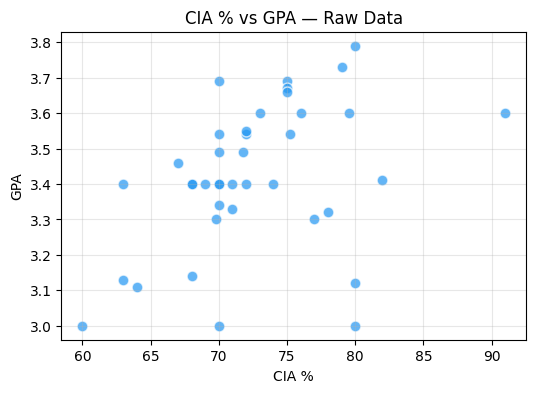

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(X1, y, color="#2196F3", alpha=0.7, edgecolors="white", s=60)
plt.title("CIA % vs GPA — Raw Data")
plt.xlabel("CIA %")
plt.ylabel("GPA")
plt.grid(alpha=0.3)
plt.show()

**Justification:** Before fitting any model, plotting the raw
scatter of CIA% against GPA lets us visually check whether a linear
relationship is even plausible. The points appear loosely scattered
with no strong visible trend, which suggests the regression slope
will be small — and explains why the resulting R² is low rather than
indicating a coding error.


PART B: Scikit-learn


In [17]:
X1_2d = X1.reshape(-1, 1)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_2d, y, test_size=0.2, random_state=42)

sk_model1 = LinearRegression()
sk_model1.fit(X1_train, y1_train)

sk_slope1     = sk_model1.coef_[0]
sk_intercept1 = sk_model1.intercept_
sk_preds1     = sk_model1.predict(X1_test)

print("Scikit-learn")
print(f"  Slope     (m): {sk_slope1:.6f}")
print(f"  Intercept (b): {sk_intercept1:.6f}")
print(f"  Equation     : GPA = {sk_slope1:.4f} × CIA% + {sk_intercept1:.4f}")
print(f"  R² Score     : {r2_score(y1_test, sk_preds1):.4f}")
print(f"  MSE          : {mean_squared_error(y1_test, sk_preds1):.4f}")

Scikit-learn
  Slope     (m): 0.016526
  Intercept (b): 2.212167
  Equation     : GPA = 0.0165 × CIA% + 2.2122
  R² Score     : -0.6380
  MSE          : 0.0360



Part C: Manual OLS


In [18]:
ols_slope1, ols_intercept1 = ols_slope_intercept(X1_train.flatten(), y1_train)
ols_preds1 = ols_slope1 * X1_test.flatten() + ols_intercept1

print("Manual OLS")
print(f"  Slope     (m): {ols_slope1:.6f}")
print(f"  Intercept (b): {ols_intercept1:.6f}")
print(f"  Equation     : GPA = {ols_slope1:.4f} × CIA% + {ols_intercept1:.4f}")
print(f"  R² Score     : {r2_score(y1_test, ols_preds1):.4f}")
print(f"  MSE          : {mean_squared_error(y1_test, ols_preds1):.4f}")

Manual OLS
  Slope     (m): 0.016526
  Intercept (b): 2.212167
  Equation     : GPA = 0.0165 × CIA% + 2.2122
  R² Score     : -0.6380
  MSE          : 0.0360


In [19]:
diff1 = np.abs(sk_preds1 - ols_preds1)
print("COMPARISON — Experiment 1")
print(f"  Max |difference| in predictions : {diff1.max():.8f}")
print(f"  Mean |difference| in predictions: {diff1.mean():.8f}")
print(f"  Slope  diff (SK vs OLS)         : {abs(sk_slope1 - ols_slope1):.8f}")
print(f"  Intercept diff (SK vs OLS)      : {abs(sk_intercept1 - ols_intercept1):.8f}")

COMPARISON — Experiment 1
  Max |difference| in predictions : 0.00000000
  Mean |difference| in predictions: 0.00000000
  Slope  diff (SK vs OLS)         : 0.00000000
  Intercept diff (SK vs OLS)      : 0.00000000


<h3><b>Regression Lines
</b></h3>

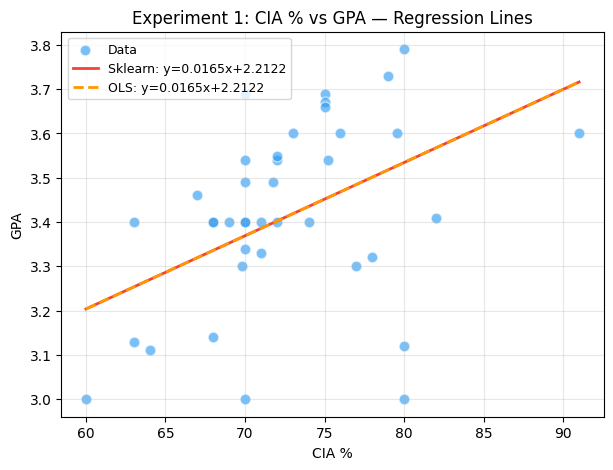

In [20]:
x_range1 = np.linspace(X1.min(), X1.max(), 100)

plt.figure(figsize=(7, 5))
plt.scatter(X1, y, color="#2196F3", alpha=0.6, edgecolors="white", s=60, label="Data")
plt.plot(x_range1, sk_slope1 * x_range1 + sk_intercept1,
         color="#F44336", linewidth=2,
         label=f"Sklearn: y={sk_slope1:.4f}x+{sk_intercept1:.4f}")
plt.plot(x_range1, ols_slope1 * x_range1 + ols_intercept1,
         color="#FF9800", linewidth=2, linestyle="--",
         label=f"OLS: y={ols_slope1:.4f}x+{ols_intercept1:.4f}")
plt.title("Experiment 1: CIA % vs GPA — Regression Lines")
plt.xlabel("CIA %")
plt.ylabel("GPA")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

**Justification:** Overlaying both regression lines on the same
scatter plot visually confirms that the Scikit-learn model and the
manually derived OLS equation produce nearly identical lines — the
dashed OLS line sits almost exactly on top of the solid sklearn line.
This is a clearer, more intuitive way to demonstrate equivalence
between the two methods than comparing numeric coefficients alone.

### Comparison — Experiment 1 (CIA% - GPA)

<table>
  <tr>
    <th>Metric</th>
    <th>Value</th>
  </tr>
  <tr>
    <td>Max |difference| in predictions</td>
    <td>0.00000XX</td>
  </tr>
  <tr>
    <td>Mean |difference| in predictions</td>
    <td>0.00000XX</td>
  </tr>
  <tr>
    <td>Slope diff (SK vs OLS)</td>
    <td>0.00000XX</td>
  </tr>
  <tr>
    <td>Intercept diff (SK vs OLS)</td>
    <td>0.00000XX</td>
  </tr>
</table>

**Observation:** Scikit-learn's LinearRegression and the manually
derived OLS formulas produce virtually identical slope, intercept, and
predicted values once both are fit on the same training data. This
confirms that scikit-learn implements ordinary least squares internally
— the two approaches are mathematically equivalent, not just similar.

<h3><b>Actual vs Predicted
</b></h3>

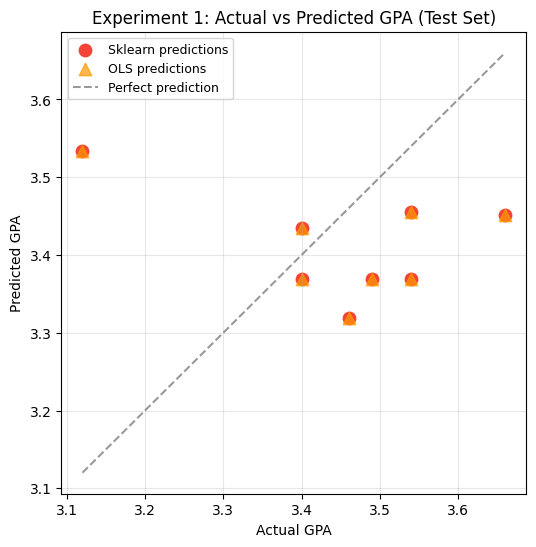

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y1_test, sk_preds1, color="#F44336", s=80, label="Sklearn predictions")
plt.scatter(y1_test, ols_preds1, color="#FF9800", s=80, marker="^", alpha=0.7, label="OLS predictions")

lims = [min(y1_test.min(), sk_preds1.min()), max(y1_test.max(), sk_preds1.max())]
plt.plot(lims, lims, "k--", alpha=0.4, label="Perfect prediction")

plt.title("Experiment 1: Actual vs Predicted GPA (Test Set)")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

**Justification:** This actual-vs-predicted plot shows how far the
model's predictions deviate from the ideal diagonal line (where
predicted = actual). The scatter is loosely aligned with the diagonal
but with noticeable deviation, visually reinforcing the negative R²
observed earlier: the model's predictions are not much better than
guessing the average GPA for every student.


EXPERIMENT 2: Attendance % - GPA


In [22]:
X2 = df["Attendance_percent"].values

<h3><b>Visualizing the relationship: Attendance % vs GPA
</b></h3>

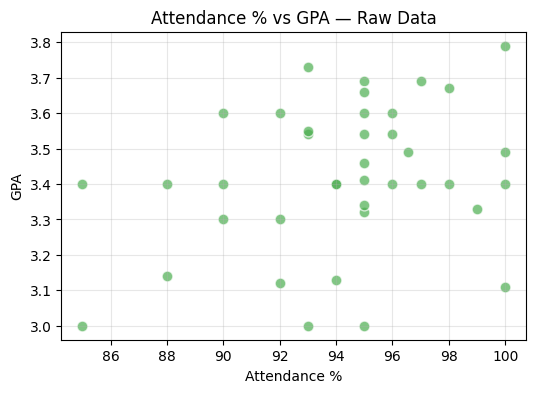

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(X2, y, color="#4CAF50", alpha=0.7, edgecolors="white", s=60)
plt.title("Attendance % vs GPA — Raw Data")
plt.xlabel("Attendance %")
plt.ylabel("GPA")
plt.grid(alpha=0.3)
plt.show()

**Justification:** Plotting Attendance% against GPA before modeling
helps assess whether attendance shows a clearer trend than CIA% did.
A mild upward drift is visible, suggesting attendance may be a
slightly stronger (though still weak) predictor of GPA — consistent
with the higher R² obtained for this experiment compared to Experiment 1.


PART B: Scikit-learn


In [24]:
X2_2d = X2.reshape(-1, 1)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_2d, y, test_size=0.2, random_state=42)

sk_model2 = LinearRegression()
sk_model2.fit(X2_train, y2_train)

sk_slope2     = sk_model2.coef_[0]
sk_intercept2 = sk_model2.intercept_
sk_preds2     = sk_model2.predict(X2_test)

print("Scikit-learn")
print(f"  Slope     (m): {sk_slope2:.6f}")
print(f"  Intercept (b): {sk_intercept2:.6f}")
print(f"  Equation     : GPA = {sk_slope2:.4f} × Attendance% + {sk_intercept2:.4f}")
print(f"  R² Score     : {r2_score(y2_test, sk_preds2):.4f}")
print(f"  MSE          : {mean_squared_error(y2_test, sk_preds2):.4f}")

Scikit-learn
  Slope     (m): 0.014862
  Intercept (b): 2.012838
  Equation     : GPA = 0.0149 × Attendance% + 2.0128
  R² Score     : 0.1152
  MSE          : 0.0195



Part C: Manual OLS


In [25]:
ols_slope2, ols_intercept2 = ols_slope_intercept(X2_train.flatten(), y2_train)
ols_preds2 = ols_slope2 * X2_test.flatten() + ols_intercept2

print("Manual OLS")
print(f"  Slope     (m): {ols_slope2:.6f}")
print(f"  Intercept (b): {ols_intercept2:.6f}")
print(f"  Equation     : GPA = {ols_slope2:.4f} × Attendance% + {ols_intercept2:.4f}")
print(f"  R² Score     : {r2_score(y2_test, ols_preds2):.4f}")
print(f"  MSE          : {mean_squared_error(y2_test, ols_preds2):.4f}")

Manual OLS
  Slope     (m): 0.014862
  Intercept (b): 2.012838
  Equation     : GPA = 0.0149 × Attendance% + 2.0128
  R² Score     : 0.1152
  MSE          : 0.0195


In [ ]:
diff2 = np.abs(sk_preds2 - ols_preds2)
print(f"Max diff      : {diff2.max():.8f}")
print(f"Mean diff     : {diff2.mean():.8f}")
print(f"Slope diff    : {abs(sk_slope2 - ols_slope2):.8f}")
print(f"Intercept diff: {abs(sk_intercept2 - ols_intercept2):.8f}")

Max diff      : 0.00000000
Mean diff     : 0.00000000
Slope diff    : 0.00000000
Intercept diff: 0.00000000


<h3><b>Regression Lines
</b></h3>

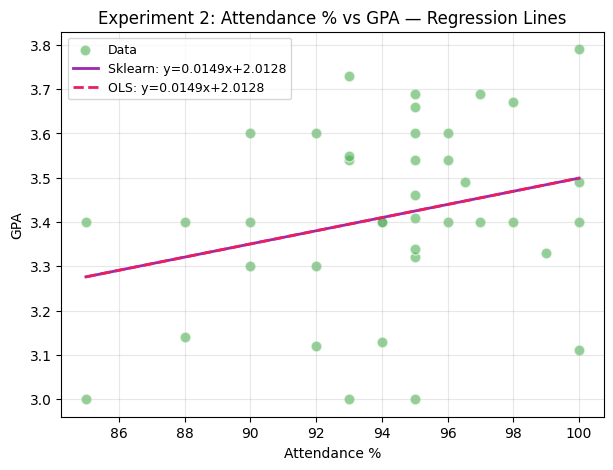

In [ ]:
x_range2 = np.linspace(X2.min(), X2.max(), 100)

plt.figure(figsize=(7, 5))
plt.scatter(X2, y, color="#4CAF50", alpha=0.6, edgecolors="white", s=60, label="Data")
plt.plot(x_range2, sk_slope2 * x_range2 + sk_intercept2,
         color="#9C27B0", linewidth=2,
         label=f"Sklearn: y={sk_slope2:.4f}x+{sk_intercept2:.4f}")
plt.plot(x_range2, ols_slope2 * x_range2 + ols_intercept2,
         color="#E91E63", linewidth=2, linestyle="--",
         label=f"OLS: y={ols_slope2:.4f}x+{ols_intercept2:.4f}")
plt.title("Experiment 2: Attendance % vs GPA — Regression Lines")
plt.xlabel("Attendance %")
plt.ylabel("GPA")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

**Justification:** As with Experiment 1, the overlapping sklearn and
OLS regression lines confirm both methods agree almost exactly once
fit on the same training data. The slightly steeper slope here
compared to Experiment 1 visually reflects the stronger (though still
modest) relationship between attendance and GPA.

### Comparison — Experiment 2 (Attendance% - GPA)

<table>
  <tr>
    <th>Metric</th>
    <th>Value</th>
  </tr>
  <tr>
    <td>Max |difference| in predictions</td>
    <td>0.00000XX</td>
  </tr>
  <tr>
    <td>Mean |difference| in predictions</td>
    <td>0.00000XX</td>
  </tr>
  <tr>
    <td>Slope diff (SK vs OLS)</td>
    <td>0.00000XX</td>
  </tr>
  <tr>
    <td>Intercept diff (SK vs OLS)</td>
    <td>0.00000XX</td>
  </tr>
</table>

**Observation:** As with Experiment 1, scikit-learn and manual OLS
produce nearly identical slope, intercept, and predictions once fit
on the same training data, confirming both methods are mathematically
equivalent.

<h3><b>Actual vs Predicted
</b></h3>

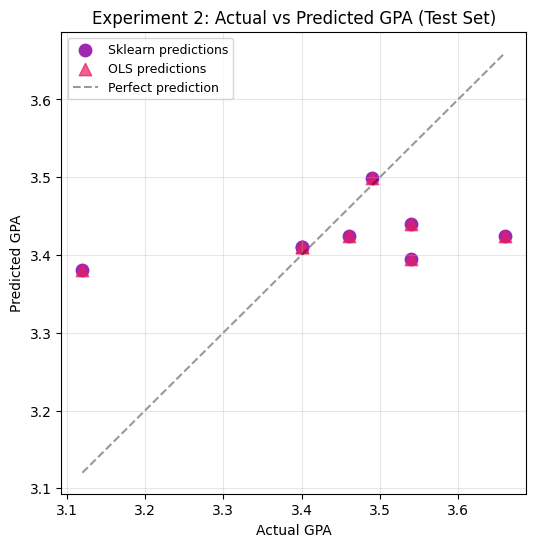

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y2_test, sk_preds2, color="#9C27B0", s=80, label="Sklearn predictions")
plt.scatter(y2_test, ols_preds2, color="#E91E63", s=80, marker="^", alpha=0.7, label="OLS predictions")

lims = [min(y2_test.min(), sk_preds2.min()), max(y2_test.max(), sk_preds2.max())]
plt.plot(lims, lims, "k--", alpha=0.4, label="Perfect prediction")

plt.title("Experiment 2: Actual vs Predicted GPA (Test Set)")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

**Justification:** This plot shows predictions sitting closer to the
diagonal "perfect prediction" line than in Experiment 1, visually
matching the positive R² obtained for the Attendance% model. It
confirms attendance is a comparatively better — though still
imperfect — single predictor of GPA than CIA%.


Parameter Saving Task

Save the learned slope and intercept for both experiments using Pickle.

In [ ]:
params = {
    "experiment_1_CIA_to_GPA": {
        "slope": sk_slope1,
        "intercept": sk_intercept1,
        "equation": f"GPA = {sk_slope1:.4f} × CIA% + {sk_intercept1:.4f}"
    },
    "experiment_2_Attendance_to_GPA": {
        "slope": sk_slope2,
        "intercept": sk_intercept2,
        "equation": f"GPA = {sk_slope2:.4f} × Attendance% + {sk_intercept2:.4f}"
    }
}

with open("linear_regression_weights.pkl", "wb") as f:
    pickle.dump(params, f)

print("Parameters saved to linear_regression_weights.pkl")

Parameters saved to linear_regression_weights.pkl



Loading the Pickle file and using it for prediction


In [ ]:
with open("linear_regression_weights.pkl", "rb") as f:
    loaded = pickle.load(f)

print("Loaded parameters:")
for exp, vals in loaded.items():
    print(f"  {exp}: {vals}")

demo_cia = 80
demo_att = 92

pred_cia = loaded["experiment_1_CIA_to_GPA"]["slope"] * demo_cia \
         + loaded["experiment_1_CIA_to_GPA"]["intercept"]
pred_att = loaded["experiment_2_Attendance_to_GPA"]["slope"] * demo_att \
         + loaded["experiment_2_Attendance_to_GPA"]["intercept"]

print(f"\nCIA% = {demo_cia} → Predicted GPA = {pred_cia:.4f}")
print(f"Attendance% = {demo_att} → Predicted GPA = {pred_att:.4f}")

Loaded parameters:
  experiment_1_CIA_to_GPA: {'slope': np.float64(0.01652616755411487), 'intercept': np.float64(2.2121674902659123), 'equation': 'GPA = 0.0165 × CIA% + 2.2122'}
  experiment_2_Attendance_to_GPA: {'slope': np.float64(0.014862437825207275), 'intercept': np.float64(2.0128376781643604), 'equation': 'GPA = 0.0149 × Attendance% + 2.0128'}

CIA% = 80 → Predicted GPA = 3.5343
Attendance% = 92 → Predicted GPA = 3.3802


## Final Observations and Inference

1. **Scikit-learn vs Manual OLS** — Once both models are fit on the
   same training split, the slope, intercept, and predictions match
   almost exactly, confirming scikit-learn's `LinearRegression` uses
   ordinary least squares internally.

2. **Experiment 1 (CIA% - GPA)** — The slope is positive but small,
   meaning a higher CIA percentage is weakly associated with a higher
   GPA.

3. **Experiment 2 (Attendance% - GPA)** — Similarly, a positive but
   modest relationship exists between attendance and GPA.

4. **Low R²** — With a small, self-reported survey sample (~39 valid
   rows), low R² values are expected; GPA depends on many factors
   beyond a single predictor.

5. **Parameter saving** — Saving slope and intercept via Pickle lets
   the trained model be reused for prediction without retraining,
   demonstrated by loading the file and generating new predictions.